# DP1 ECDFS coverage figure

This notebook builds the sky-coverage figure for the DP1 ECDFS
LSST--VISTA fusion paper.

At this stage the figure contains:

- the five DP1 ECDFS tract boundaries;
- the LSST SkyMap patch grid;
- approximate VIDEO CDFS1, CDFS2, and CDFS3 field envelopes;
- a cached table describing the actual valid ComCam coverage of each patch.

The expensive pixel-level patch-coverage calculation is **not repeated**
here. It was run once separately and should be saved as a CSV file before
using this clean notebook.

Later cells can be added to replace the approximate VIDEO rectangles with
the exact VISTA image footprints and to highlight a representative patch
for the multi-band inset figure.


## 1. Imports and plotting setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Polygon, Rectangle

import lsst.daf.butler as dafButler
import lsst.geom as geom


# Use PNG for inline notebook rendering.
%matplotlib inline
%config InlineBackend.figure_format = "png"


# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

OUTDIR = Path("data/image_products")
OUTDIR.mkdir(parents=True, exist_ok=True)

COVERAGE_CACHE = Path(
    "data/coverage/dp1_ecdfs_comcam_patch_coverage.csv"
)

OUTPUT_PNG = OUTDIR / "dp1_ecdfs_coverage_working.png"
OUTPUT_PDF = OUTDIR / "dp1_ecdfs_coverage_working.pdf"

## 2. Butler, SkyMap, and ECDFS tracts

In [2]:
COMCAM_REPO = "dp1"
COMCAM_COLLECTION = "LSSTComCam/DP1"

butler = dafButler.Butler(
    COMCAM_REPO,
    collections=COMCAM_COLLECTION,
)

sky_map = butler.get("skyMap")


# Five DP1 tracts covering the ECDFS region.
TRACT_IDS = [
    5062,
    5063,
    5064,
    4848,
    4849,
]

TRACT_COLOURS = {
    5062: "tab:green",
    5063: "tab:blue",
    5064: "tab:orange",
    4848: "tab:purple",
    4849: "tab:brown",
}

print("Opened Butler:", COMCAM_REPO)
print("ECDFS tracts:", TRACT_IDS)

Opened Butler: dp1
ECDFS tracts: [5062, 5063, 5064, 4848, 4849]


## 3. Approximate VIDEO field envelopes

These rectangles are useful for checking the large-scale geometry.
They will later be replaced by the exact footprints derived from the
individual VISTA image headers.


In [3]:
video_fields = {
    "CDFS3": {
        "ra_min": 53.2917,
        "ra_max": 54.6000,
        "dec_min": -28.7167,
        "dec_max": -27.2167,
        "color": "orange",
    },
    "CDFS2": {
        "ra_min": 51.7000,
        "ra_max": 53.4000,
        "dec_min": -29.2167,
        "dec_max": -28.0333,
        "color": "green",
    },
    "CDFS1": {
        "ra_min": 51.7000,
        "ra_max": 53.4000,
        "dec_min": -28.1667,
        "dec_max": -26.9667,
        "color": "purple",
    },
}

video_fields

{'CDFS3': {'ra_min': 53.2917,
  'ra_max': 54.6,
  'dec_min': -28.7167,
  'dec_max': -27.2167,
  'color': 'orange'},
 'CDFS2': {'ra_min': 51.7,
  'ra_max': 53.4,
  'dec_min': -29.2167,
  'dec_max': -28.0333,
  'color': 'green'},
 'CDFS1': {'ra_min': 51.7,
  'ra_max': 53.4,
  'dec_min': -28.1667,
  'dec_max': -26.9667,
  'color': 'purple'}}

## 4. Geometry helpers

In [4]:
def bbox_sky_vertices(bbox, wcs):
    """
    Convert an LSST parent-pixel bounding box to four ICRS vertices.

    Returns
    -------
    vertices : numpy.ndarray
        Shape (4, 2), with columns RA [deg] and Dec [deg].
    """
    pixel_vertices = [
        geom.Point2D(bbox.getMinX(), bbox.getMinY()),
        geom.Point2D(bbox.getMaxX(), bbox.getMinY()),
        geom.Point2D(bbox.getMaxX(), bbox.getMaxY()),
        geom.Point2D(bbox.getMinX(), bbox.getMaxY()),
    ]

    sky_vertices = [
        wcs.pixelToSky(point)
        for point in pixel_vertices
    ]

    return np.array(
        [
            [
                sky.getRa().asDegrees(),
                sky.getDec().asDegrees(),
            ]
            for sky in sky_vertices
        ],
        dtype=float,
    )


def add_sky_polygon(
    ax,
    vertices,
    edgecolor,
    linewidth=1.0,
    facecolor="none",
    alpha=1.0,
    zorder=1,
):
    """Add one RA/Dec polygon to an axis."""
    polygon = Polygon(
        vertices,
        closed=True,
        edgecolor=edgecolor,
        facecolor=facecolor,
        linewidth=linewidth,
        alpha=alpha,
        zorder=zorder,
    )

    ax.add_patch(polygon)

    return polygon

## 5. Load the cached ComCam patch-coverage measurements

The coverage table was generated by measuring the fraction of pixels not
flagged `NO_DATA` in each ComCam band for every ECDFS patch. That full
calculation takes roughly 14 minutes on the RSP and is intentionally not
included in this notebook.

Before using this cell for the first time, save the already-computed
`coverage_table` from the exploratory notebook to the path defined by
`COVERAGE_CACHE`.


In [5]:
if not COVERAGE_CACHE.exists():
    raise FileNotFoundError(
        f"Coverage cache not found: {COVERAGE_CACHE}\n\n"
        "Save the already-computed coverage_table from the exploratory "
        "notebook first, then rerun this cell."
    )

coverage_table = pd.read_csv(COVERAGE_CACHE)

required_columns = {
    "tract",
    "patch",
    "u_valid_fraction",
    "g_valid_fraction",
    "r_valid_fraction",
    "i_valid_fraction",
    "z_valid_fraction",
    "y_valid_fraction",
    "n_bands",
    "n_bands_50pct",
    "n_bands_80pct",
    "median_valid_fraction",
    "minimum_valid_fraction",
}

missing_columns = required_columns - set(coverage_table.columns)

if missing_columns:
    raise ValueError(
        "Coverage cache is missing columns: "
        + ", ".join(sorted(missing_columns))
    )

coverage_table = coverage_table.sort_values(
    ["tract", "patch"]
).reset_index(drop=True)

print(
    f"Loaded {len(coverage_table)} patch rows from "
    f"{COVERAGE_CACHE}"
)

display(
    coverage_table[
        [
            "tract",
            "patch",
            "n_bands",
            "n_bands_50pct",
            "n_bands_80pct",
            "median_valid_fraction",
            "minimum_valid_fraction",
        ]
    ]
)

Loaded 91 patch rows from data/coverage/dp1_ecdfs_comcam_patch_coverage.csv


,tract,patch,n_bands,n_bands_50pct,n_bands_80pct,median_valid_fraction,minimum_valid_fraction
0,4848,60,6,0,0,0.225742,0.112304
1,4848,61,4,0,0,0.165497,0.092991
2,4848,70,6,6,6,0.994121,0.920075
3,4848,71,6,6,3,0.872653,0.578937
4,4848,72,6,1,0,0.377438,0.057121
...,...,...,...,...,...,...,...
86,5063,57,0,0,0,0.000000,0.000000
87,5064,9,6,0,0,0.170016,0.045755
88,5064,19,6,0,0,0.383000,0.071417
89,5064,29,4,0,0,0.156443,0.092815


## 6. Useful-coverage summary

For the next plotting step, we keep patches with valid data in at least
four of the six ComCam bands. This is only a first selection criterion:
the valid-area fractions are retained so that partial edge patches can be
distinguished from well-covered patches rather than being drawn as fully
observed.


In [6]:
coverage_4band = coverage_table[
    coverage_table["n_bands"] >= 4
].copy()

print(
    f"{len(coverage_4band)} patches have valid coverage "
    "in at least four ComCam bands."
)

display(
    coverage_4band[
        [
            "tract",
            "patch",
            "n_bands",
            "n_bands_50pct",
            "n_bands_80pct",
            "median_valid_fraction",
            "minimum_valid_fraction",
        ]
    ].sort_values(
        ["tract", "patch"]
    )
)

81 patches have valid coverage in at least four ComCam bands.


,tract,patch,n_bands,n_bands_50pct,n_bands_80pct,median_valid_fraction,minimum_valid_fraction
0,4848,60,6,0,0,0.225742,0.112304
1,4848,61,4,0,0,0.165497,0.092991
2,4848,70,6,6,6,0.994121,0.920075
3,4848,71,6,6,3,0.872653,0.578937
4,4848,72,6,1,0,0.377438,0.057121
...,...,...,...,...,...,...,...
84,5063,55,6,0,0,0.327425,0.010082
85,5063,56,5,0,0,0.087743,0.072400
87,5064,9,6,0,0,0.170016,0.045755
88,5064,19,6,0,0,0.383000,0.071417


## 7. Working coverage map

This is the geometry-check version of the figure. Thin grey lines show
the complete SkyMap patch grid; coloured lines show tract boundaries;
transparent rectangles show the approximate VIDEO field envelopes.

The plot uses explicit ECDFS axis limits rather than `bbox_inches="tight"`
because an earlier RSP rendering problem was triggered when Matplotlib
attempted to determine tight bounds for the many SkyMap polygons.


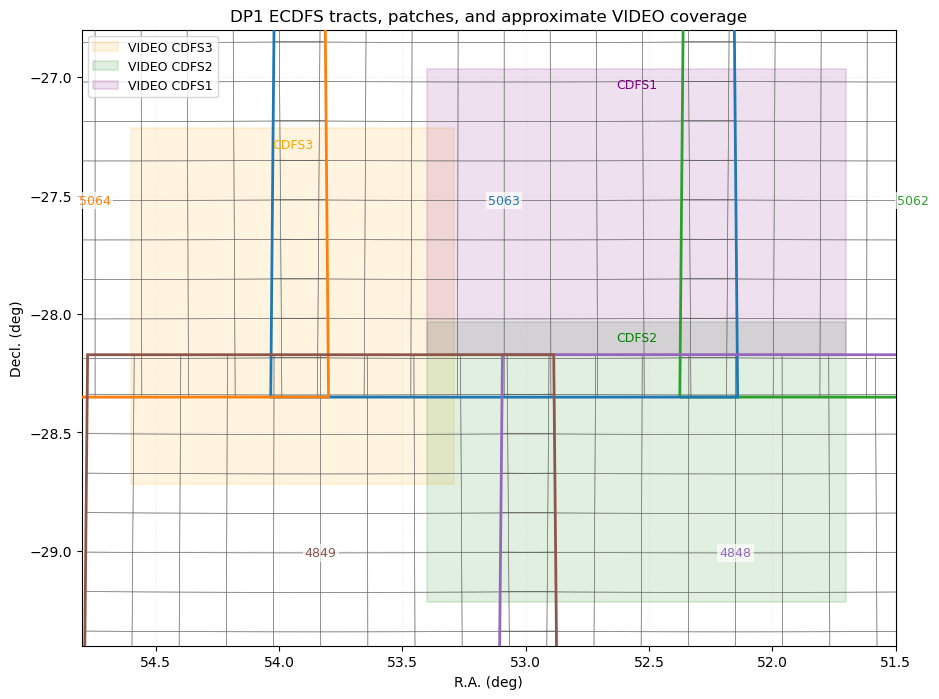

Saved PNG: data/image_products/dp1_ecdfs_coverage_working.png
Saved PDF: data/image_products/dp1_ecdfs_coverage_working.pdf


In [7]:
fig, ax = plt.subplots(
    figsize=(10.5, 8.0),
)


# ------------------------------------------------------------
# Approximate VIDEO field envelopes
# ------------------------------------------------------------

for field_name, field in video_fields.items():
    width = (
        field["ra_max"]
        - field["ra_min"]
    )

    height = (
        field["dec_max"]
        - field["dec_min"]
    )

    rectangle = Rectangle(
        (
            field["ra_min"],
            field["dec_min"],
        ),
        width,
        height,
        facecolor=field["color"],
        edgecolor=field["color"],
        linewidth=1.5,
        alpha=0.12,
        label=f"VIDEO {field_name}",
        zorder=1,
    )

    ax.add_patch(rectangle)

    ax.text(
        0.5 * (
            field["ra_min"]
            + field["ra_max"]
        ),
        field["dec_max"] - 0.04,
        field_name,
        ha="center",
        va="top",
        fontsize=9,
        color=field["color"],
        zorder=5,
    )


# ------------------------------------------------------------
# DP1 tracts and full SkyMap patch grid
# ------------------------------------------------------------

for tract_id in TRACT_IDS:
    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    tract_vertices = bbox_sky_vertices(
        tract_info.getBBox(),
        tract_wcs,
    )

    add_sky_polygon(
        ax,
        tract_vertices,
        edgecolor=TRACT_COLOURS[tract_id],
        linewidth=2.0,
        facecolor="none",
        zorder=4,
    )

    tract_centre = tract_info.getCtrCoord()

    ax.text(
        tract_centre.getRa().asDegrees(),
        tract_centre.getDec().asDegrees(),
        str(tract_id),
        ha="center",
        va="center",
        fontsize=9,
        color=TRACT_COLOURS[tract_id],
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.70,
            "pad": 1.5,
        },
        zorder=6,
    )

    number_of_patches = tract_info.getNumPatches()

    for patch_y in range(number_of_patches[1]):
        for patch_x in range(number_of_patches[0]):
            patch_info = tract_info.getPatchInfo(
                (patch_x, patch_y)
            )

            patch_vertices = bbox_sky_vertices(
                patch_info.getInnerBBox(),
                tract_wcs,
            )

            add_sky_polygon(
                ax,
                patch_vertices,
                edgecolor="0.35",
                linewidth=0.45,
                facecolor="none",
                alpha=0.65,
                zorder=3,
            )


# ------------------------------------------------------------
# Appearance
# ------------------------------------------------------------

ax.set_xlabel("R.A. (deg)")
ax.set_ylabel("Decl. (deg)")

ax.set_title(
    "DP1 ECDFS tracts, patches, and approximate VIDEO coverage"
)

# Explicit ECDFS limits; decreasing RA gives astronomical orientation.
ax.set_xlim(54.8, 51.5)
ax.set_ylim(-29.4, -26.8)

ax.grid(
    linestyle=":",
    linewidth=0.5,
    alpha=0.35,
)

ax.set_aspect("auto")

ax.legend(
    loc="upper left",
    fontsize=9,
    frameon=True,
)

fig.savefig(
    OUTPUT_PNG,
    dpi=150,
)

fig.savefig(
    OUTPUT_PDF,
    dpi=150,
)

plt.show()

print("Saved PNG:", OUTPUT_PNG)
print("Saved PDF:", OUTPUT_PDF)

### 8. Add the actual ComCam-covered patches

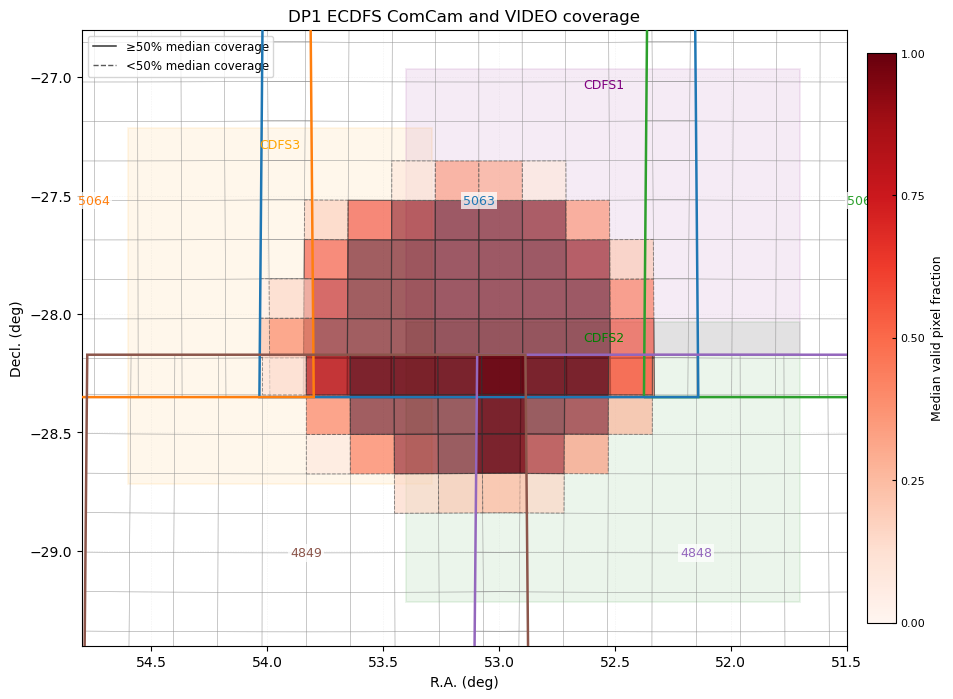

Saved PNG: data/image_products/dp1_ecdfs_comcam_patch_coverage.png
Saved PDF: data/image_products/dp1_ecdfs_comcam_patch_coverage.pdf


In [8]:
# ------------------------------------------------------------
# Coverage-aware DP1 patch map
#
# Colour intensity:
#     median valid pixel fraction across available ComCam bands
#
# Border:
#     solid  -> median valid fraction >= 0.5
#     dashed -> partial edge patch (< 0.5)
#
# Only patches with valid data in >= 4 ComCam bands are coloured.
# ------------------------------------------------------------

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Fast lookup table
# ------------------------------------------------------------

coverage_lookup = (
    coverage_4band
    .set_index(["tract", "patch"])
    .to_dict(orient="index")
)


# ------------------------------------------------------------
# Coverage colour scale
# ------------------------------------------------------------

coverage_cmap = plt.get_cmap("Reds")

coverage_norm = Normalize(
    vmin=0.0,
    vmax=1.0,
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 8.0),
)


# ------------------------------------------------------------
# Approximate VIDEO field envelopes
# ------------------------------------------------------------

for field_name, field in video_fields.items():

    width = (
        field["ra_max"]
        - field["ra_min"]
    )

    height = (
        field["dec_max"]
        - field["dec_min"]
    )

    rectangle = Rectangle(
        (
            field["ra_min"],
            field["dec_min"],
        ),
        width,
        height,
        facecolor=field["color"],
        edgecolor=field["color"],
        linewidth=1.4,
        alpha=0.08,
        zorder=1,
    )

    ax.add_patch(rectangle)

    ax.text(
        0.5 * (
            field["ra_min"]
            + field["ra_max"]
        ),
        field["dec_max"] - 0.04,
        field_name,
        ha="center",
        va="top",
        fontsize=9,
        color=field["color"],
        zorder=7,
    )


# ------------------------------------------------------------
# First layer:
# full SkyMap patch grid
# ------------------------------------------------------------

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    number_of_patches = tract_info.getNumPatches()

    for patch_y in range(number_of_patches[1]):

        for patch_x in range(number_of_patches[0]):

            patch_info = tract_info.getPatchInfo(
                (patch_x, patch_y)
            )

            patch_vertices = bbox_sky_vertices(
                patch_info.getInnerBBox(),
                tract_wcs,
            )

            # All geometrical patches:
            # deliberately very light.
            polygon = Polygon(
                patch_vertices,
                closed=True,
                facecolor="none",
                edgecolor="0.55",
                linewidth=0.35,
                alpha=0.55,
                zorder=2,
            )

            ax.add_patch(polygon)


# ------------------------------------------------------------
# Second layer:
# patches with >= 4 available ComCam bands
# ------------------------------------------------------------

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    number_of_patches = tract_info.getNumPatches()

    for patch_y in range(number_of_patches[1]):

        for patch_x in range(number_of_patches[0]):

            patch_info = tract_info.getPatchInfo(
                (patch_x, patch_y)
            )

            # Sequential patch ID used by Butler.
            patch_id = patch_info.getSequentialIndex()

            key = (
                tract_id,
                patch_id,
            )

            if key not in coverage_lookup:
                continue

            row = coverage_lookup[key]

            median_fraction = float(
                row["median_valid_fraction"]
            )

            patch_vertices = bbox_sky_vertices(
                patch_info.getInnerBBox(),
                tract_wcs,
            )


            # ----------------------------------------------
            # Distinguish edge patches from substantial ones
            # ----------------------------------------------

            if median_fraction >= 0.50:

                linestyle = "-"
                linewidth = 0.85
                edgecolor = "0.20"

            else:

                linestyle = "--"
                linewidth = 0.70
                edgecolor = "0.35"


            polygon = Polygon(
                patch_vertices,
                closed=True,
                facecolor=coverage_cmap(
                    coverage_norm(
                        median_fraction
                    )
                ),
                edgecolor=edgecolor,
                linewidth=linewidth,
                linestyle=linestyle,
                alpha=0.62,
                zorder=3,
            )

            ax.add_patch(polygon)


# ------------------------------------------------------------
# Third layer:
# tract boundaries
# ------------------------------------------------------------

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    tract_vertices = bbox_sky_vertices(
        tract_info.getBBox(),
        tract_wcs,
    )

    add_sky_polygon(
        ax,
        tract_vertices,
        edgecolor=TRACT_COLOURS[tract_id],
        linewidth=1.8,
        facecolor="none",
        zorder=6,
    )

    tract_centre = tract_info.getCtrCoord()

    ax.text(
        tract_centre.getRa().asDegrees(),
        tract_centre.getDec().asDegrees(),
        str(tract_id),
        ha="center",
        va="center",
        fontsize=9,
        color=TRACT_COLOURS[tract_id],
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.75,
            "pad": 1.5,
        },
        zorder=8,
    )


# ------------------------------------------------------------
# Coverage colourbar
# ------------------------------------------------------------

coverage_mappable = ScalarMappable(
    norm=coverage_norm,
    cmap=coverage_cmap,
)

coverage_mappable.set_array([])

cbar = fig.colorbar(
    coverage_mappable,
    ax=ax,
    fraction=0.035,
    pad=0.025,
)

cbar.set_label(
    "Median valid pixel fraction",
    fontsize=9,
)

cbar.set_ticks(
    [
        0.0,
        0.25,
        0.50,
        0.75,
        1.0,
    ]
)

cbar.ax.tick_params(
    labelsize=8,
    length=3,
    direction="in",
)


# ------------------------------------------------------------
# Compact explanation of border styles
# ------------------------------------------------------------

coverage_handles = [
    Line2D(
        [0],
        [0],
        color="0.20",
        linewidth=1.1,
        linestyle="-",
        label=r"≥50% median coverage",
    ),

    Line2D(
        [0],
        [0],
        color="0.35",
        linewidth=1.0,
        linestyle="--",
        label=r"<50% median coverage",
    ),
]

ax.legend(
    handles=coverage_handles,
    loc="upper left",
    fontsize=8.5,
    frameon=True,
)


# ------------------------------------------------------------
# Appearance
# ------------------------------------------------------------

ax.set_xlabel(
    "R.A. (deg)"
)

ax.set_ylabel(
    "Decl. (deg)"
)

ax.set_title(
    "DP1 ECDFS ComCam and VIDEO coverage"
)

ax.set_xlim(
    54.8,
    51.5,
)

ax.set_ylim(
    -29.4,
    -26.8,
)

ax.grid(
    linestyle=":",
    linewidth=0.45,
    alpha=0.25,
)

ax.set_aspect(
    "auto"
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

coverage_patch_png = (
    OUTDIR
    / "dp1_ecdfs_comcam_patch_coverage.png"
)

coverage_patch_pdf = (
    OUTDIR
    / "dp1_ecdfs_comcam_patch_coverage.pdf"
)

fig.savefig(
    coverage_patch_png,
    dpi=180,
)

fig.savefig(
    coverage_patch_pdf,
    dpi=180,
)

plt.show()

print(
    "Saved PNG:",
    coverage_patch_png,
)

print(
    "Saved PDF:",
    coverage_patch_pdf,
)

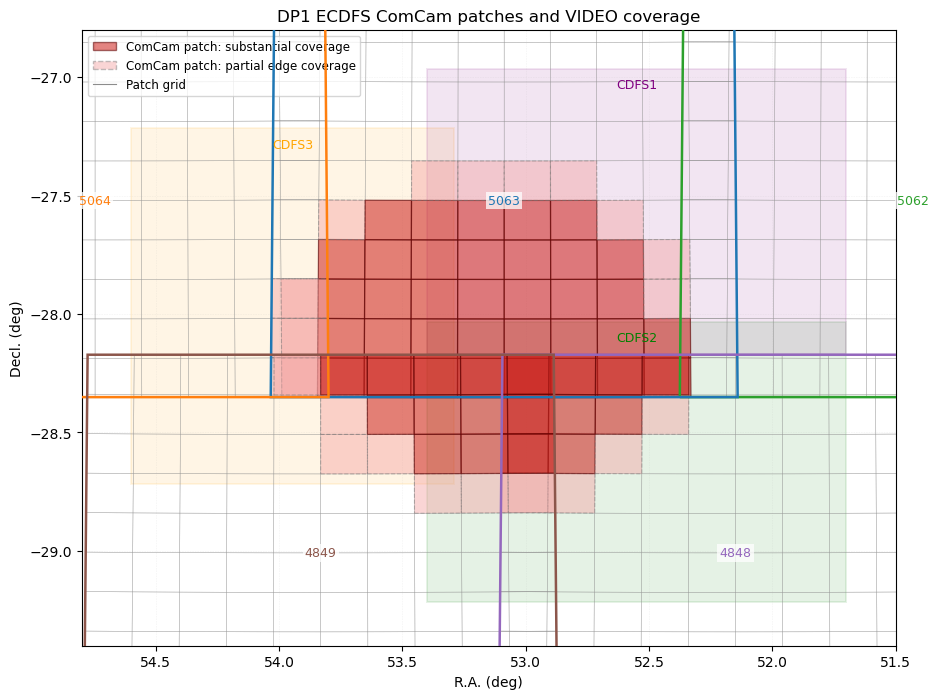

Saved PNG: data/image_products/dp1_ecdfs_comcam_patch_coverage_simple.png
Saved PDF: data/image_products/dp1_ecdfs_comcam_patch_coverage_simple.pdf


In [9]:
# ------------------------------------------------------------
# Simplified coverage map:
#   dark red  = substantial ComCam coverage
#   light red = partial/boundary coverage
# ------------------------------------------------------------

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ------------------------------------------------------------
# Build a lookup table from the cached coverage table
# ------------------------------------------------------------

coverage_lookup = (
    coverage_table
    .set_index(["tract", "patch"])
    .to_dict(orient="index")
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 8.0),
)


# ------------------------------------------------------------
# Approximate VIDEO field envelopes
# ------------------------------------------------------------

for field_name, field in video_fields.items():

    width = field["ra_max"] - field["ra_min"]
    height = field["dec_max"] - field["dec_min"]

    rectangle = Rectangle(
        (field["ra_min"], field["dec_min"]),
        width,
        height,
        facecolor=field["color"],
        edgecolor=field["color"],
        linewidth=1.4,
        alpha=0.10,
        zorder=1,
    )

    ax.add_patch(rectangle)

    ax.text(
        0.5 * (field["ra_min"] + field["ra_max"]),
        field["dec_max"] - 0.04,
        field_name,
        ha="center",
        va="top",
        fontsize=9,
        color=field["color"],
        zorder=7,
    )


# ------------------------------------------------------------
# First layer: full SkyMap patch grid
# ------------------------------------------------------------

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    number_of_patches = tract_info.getNumPatches()

    for patch_y in range(number_of_patches[1]):
        for patch_x in range(number_of_patches[0]):

            patch_info = tract_info.getPatchInfo(
                (patch_x, patch_y)
            )

            patch_vertices = bbox_sky_vertices(
                patch_info.getInnerBBox(),
                tract_wcs,
            )

            polygon = Polygon(
                patch_vertices,
                closed=True,
                facecolor="none",
                edgecolor="0.55",
                linewidth=0.35,
                alpha=0.55,
                zorder=2,
            )

            ax.add_patch(polygon)


# ------------------------------------------------------------
# Second layer: simplified ComCam coverage
# ------------------------------------------------------------

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    number_of_patches = tract_info.getNumPatches()

    for patch_y in range(number_of_patches[1]):
        for patch_x in range(number_of_patches[0]):

            patch_info = tract_info.getPatchInfo(
                (patch_x, patch_y)
            )

            patch_id = patch_info.getSequentialIndex()

            key = (tract_id, patch_id)

            if key not in coverage_lookup:
                continue

            row = coverage_lookup[key]

            # Require useful coverage in at least 4 bands.
            if row["n_bands"] < 4:
                continue

            median_fraction = float(
                row["median_valid_fraction"]
            )

            patch_vertices = bbox_sky_vertices(
                patch_info.getInnerBBox(),
                tract_wcs,
            )

            # Two simple states only:
            # substantial coverage versus partial edge coverage.
            if median_fraction >= 0.50:
                facecolor = "#cc1f1a"   # dark red
                edgecolor = "#5c0000"
                alpha = 0.55
                linestyle = "-"
                linewidth = 0.9
            else:
                facecolor = "#f4a3a3"   # light red
                edgecolor = "#777777"
                alpha = 0.45
                linestyle = "--"
                linewidth = 0.8

            polygon = Polygon(
                patch_vertices,
                closed=True,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth,
                linestyle=linestyle,
                alpha=alpha,
                zorder=3,
            )

            ax.add_patch(polygon)


# ------------------------------------------------------------
# Third layer: tract boundaries
# ------------------------------------------------------------

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    tract_vertices = bbox_sky_vertices(
        tract_info.getBBox(),
        tract_wcs,
    )

    add_sky_polygon(
        ax,
        tract_vertices,
        edgecolor=TRACT_COLOURS[tract_id],
        linewidth=1.8,
        facecolor="none",
        zorder=6,
    )

    tract_centre = tract_info.getCtrCoord()

    ax.text(
        tract_centre.getRa().asDegrees(),
        tract_centre.getDec().asDegrees(),
        str(tract_id),
        ha="center",
        va="center",
        fontsize=9,
        color=TRACT_COLOURS[tract_id],
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.75,
            "pad": 1.5,
        },
        zorder=8,
    )


# ------------------------------------------------------------
# Small, simple legend
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor="#cc1f1a",
        edgecolor="#5c0000",
        label="ComCam patch: substantial coverage",
        alpha=0.55,
    ),
    Patch(
        facecolor="#f4a3a3",
        edgecolor="#777777",
        linestyle="--",
        label="ComCam patch: partial edge coverage",
        alpha=0.45,
    ),
    Line2D(
        [0], [0],
        color="0.55",
        linewidth=0.8,
        label="Patch grid",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    fontsize=8.5,
    frameon=True,
)


# ------------------------------------------------------------
# Appearance
# ------------------------------------------------------------

ax.set_xlabel("R.A. (deg)")
ax.set_ylabel("Decl. (deg)")

ax.set_title(
    "DP1 ECDFS ComCam patches and VIDEO coverage"
)

ax.set_xlim(54.8, 51.5)
ax.set_ylim(-29.4, -26.8)

ax.grid(
    linestyle=":",
    linewidth=0.45,
    alpha=0.25,
)

ax.set_aspect("auto")


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

coverage_simple_png = (
    OUTDIR / "dp1_ecdfs_comcam_patch_coverage_simple.png"
)

coverage_simple_pdf = (
    OUTDIR / "dp1_ecdfs_comcam_patch_coverage_simple.pdf"
)

fig.savefig(
    coverage_simple_png,
    dpi=180,
)

fig.savefig(
    coverage_simple_pdf,
    dpi=180,
)

plt.show()

print("Saved PNG:", coverage_simple_png)
print("Saved PDF:", coverage_simple_pdf)

In [10]:
# ------------------------------------------------------------
# Open the LSST-VISTA fusion Butler
# ------------------------------------------------------------

VIRCAM_REPO = "lsst-ir-fusion-dp1"
VIRCAM_DATASET_TYPE = "deepCoadd_calexp"

SKYMAP = "lsst_cells_v1"

# Search all collections in the fusion repository.
VIRCAM_SEARCH_COLLECTIONS = ...

butler_vista = dafButler.Butler(
    VIRCAM_REPO
)

registry_vista = butler_vista.registry

print("Opened VIRCAM Butler:", VIRCAM_REPO)


# ------------------------------------------------------------
# Check data availability for one representative patch
# ------------------------------------------------------------

TRACT_FOR_PATCH = 5063
PATCH_FOR_PATCH = 34

COMCAM_BANDS = ["u", "g", "r", "i", "z", "y"]
VIRCAM_BANDS = ["Z", "Y", "J", "H", "K"]

print(
    f"Checking tract {TRACT_FOR_PATCH}, patch {PATCH_FOR_PATCH}"
)

for band in COMCAM_BANDS:
    refs = list(
        butler.query_datasets(
            "deep_coadd",
            tract=TRACT_FOR_PATCH,
            patch=PATCH_FOR_PATCH,
            where=f"band = '{band}'",
            explain=False,
        )
    )

    print(
        f"ComCam {band}:",
        "OK" if len(refs) > 0 else "missing",
    )


for band in VIRCAM_BANDS:
    refs = list(
        registry_vista.queryDatasets(
            VIRCAM_DATASET_TYPE,
            dataId={
                "skymap": SKYMAP,
                "tract": TRACT_FOR_PATCH,
                "patch": PATCH_FOR_PATCH,
                "band": band,
            },
            collections=VIRCAM_SEARCH_COLLECTIONS,
        )
    )

    print(
        f"VIRCAM {band}:",
        "OK" if len(refs) > 0 else "missing",
    )

Opened VIRCAM Butler: lsst-ir-fusion-dp1
Checking tract 5063, patch 34
ComCam u: OK
ComCam g: OK
ComCam r: OK
ComCam i: OK
ComCam z: OK
ComCam y: OK
VIRCAM Z: OK
VIRCAM Y: OK
VIRCAM J: OK
VIRCAM H: OK
VIRCAM K: OK


ComCam  u: (3400, 3400) -> display (850, 850)
ComCam  g: (3400, 3400) -> display (850, 850)
ComCam  r: (3400, 3400) -> display (850, 850)
ComCam  i: (3400, 3400) -> display (850, 850)
ComCam  z: (3400, 3400) -> display (850, 850)
ComCam  y: (3400, 3400) -> display (850, 850)
VIRCAM  Z: (3400, 3400) -> display (850, 850)
VIRCAM  Y: (3400, 3400) -> display (850, 850)
VIRCAM  J: (3400, 3400) -> display (850, 850)
VIRCAM  H: (3400, 3400) -> display (850, 850)
VIRCAM  K: (3400, 3400) -> display (850, 850)


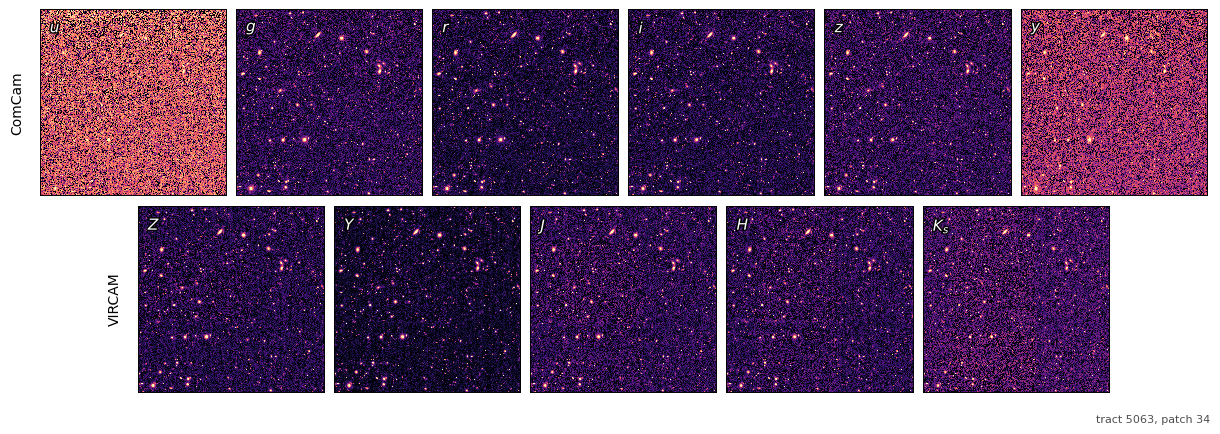

Saved PNG: data/image_products/dp1_ecdfs_11band_patch_5063_34.png
Saved PDF: data/image_products/dp1_ecdfs_11band_patch_5063_34.pdf


In [11]:
# ============================================================
# Representative patch in all 11 bands
# ============================================================

from astropy.visualization import ImageNormalize, AsinhStretch
import matplotlib.patheffects as pe


# ------------------------------------------------------------
# Selection
# ------------------------------------------------------------

TRACT_FOR_PATCH = 5063
PATCH_FOR_PATCH = 34

COMCAM_BANDS = ["u", "g", "r", "i", "z", "y"]
VIRCAM_BANDS = ["Z", "Y", "J", "H", "K"]
ALL_BANDS = COMCAM_BANDS + VIRCAM_BANDS

PANEL_LABELS = {
    "u": r"$u$",
    "g": r"$g$",
    "r": r"$r$",
    "i": r"$i$",
    "z": r"$z$",
    "y": r"$y$",
    "Z": r"$Z$",
    "Y": r"$Y$",
    "J": r"$J$",
    "H": r"$H$",
    "K": r"$K_s$",
}

DISPLAY_CMAP = "magma"
DISPLAY_ASINH_A = 0.04

# Maximum displayed dimension.
# The science data themselves are not modified; this is only
# to keep the figure light enough for the notebook/PDF.
MAX_DISPLAY_PIXELS = 900


# ------------------------------------------------------------
# Butler helpers
# ------------------------------------------------------------

def load_comcam_patch(band):
    """Load one ComCam coadd for the selected tract and patch."""

    refs = list(
        butler.query_datasets(
            "deep_coadd",
            tract=TRACT_FOR_PATCH,
            patch=PATCH_FOR_PATCH,
            where=f"band = '{band}'",
            explain=False,
        )
    )

    if not refs:
        raise RuntimeError(
            f"No ComCam {band}-band dataset for "
            f"tract={TRACT_FOR_PATCH}, patch={PATCH_FOR_PATCH}."
        )

    ref = sorted(
        refs,
        key=lambda item: str(item.run),
    )[-1]

    return butler.get(ref), ref


def load_vista_patch(band):
    """Load one VIRCAM coadd for the selected tract and patch."""

    refs = list(
        registry_vista.queryDatasets(
            VIRCAM_DATASET_TYPE,
            dataId={
                "skymap": SKYMAP,
                "tract": TRACT_FOR_PATCH,
                "patch": PATCH_FOR_PATCH,
                "band": band,
            },
            collections=VIRCAM_SEARCH_COLLECTIONS,
        )
    )

    if not refs:
        raise RuntimeError(
            f"No VIRCAM {band}-band dataset for "
            f"tract={TRACT_FOR_PATCH}, patch={PATCH_FOR_PATCH}."
        )

    # Prefer the validated fusion run when it is visible.
    if "VIRCAM_PREFERRED_RUN" in globals():

        preferred = [
            ref
            for ref in refs
            if ref.run == VIRCAM_PREFERRED_RUN
        ]

    else:
        preferred = []

    ref = (
        preferred[0]
        if preferred
        else sorted(
            refs,
            key=lambda item: str(item.run),
        )[-1]
    )

    return butler_vista.get(ref), ref


# ------------------------------------------------------------
# Mask helper
# ------------------------------------------------------------

def get_no_data_mask(exposure):
    """Return the NO_DATA mask for one exposure."""

    mask = exposure.mask
    plane_dict = mask.getMaskPlaneDict()

    if "NO_DATA" not in plane_dict:
        return np.zeros(
            mask.array.shape,
            dtype=bool,
        )

    bit = plane_dict["NO_DATA"]

    return (
        np.asarray(mask.array, dtype=np.int64)
        & (1 << bit)
    ) != 0


# ------------------------------------------------------------
# Robust image normalization
# ------------------------------------------------------------

def make_patch_display(exposure):
    """
    Prepare a downsampled display image and an independent
    robust asinh normalization.
    """

    image = np.asarray(
        exposure.image.array,
        dtype=float,
    ).copy()

    no_data = get_no_data_mask(exposure)

    image[no_data] = np.nan

    ny, nx = image.shape

    display_step = max(
        1,
        int(
            np.ceil(
                max(nx, ny)
                / MAX_DISPLAY_PIXELS
            )
        ),
    )

    display_image = image[
        ::display_step,
        ::display_step,
    ]

    valid = display_image[
        np.isfinite(display_image)
    ]

    if valid.size == 0:
        raise RuntimeError(
            "No valid pixels available for display."
        )

    median = np.median(valid)

    mad = np.median(
        np.abs(valid - median)
    )

    sigma = 1.4826 * mad

    if not np.isfinite(sigma) or sigma <= 0:
        sigma = np.std(valid)

    vmin = median - 1.0 * sigma
    vmax = np.percentile(
        valid,
        99.7,
    )

    norm = ImageNormalize(
        vmin=vmin,
        vmax=vmax,
        stretch=AsinhStretch(
            a=DISPLAY_ASINH_A
        ),
        clip=True,
    )

    return (
        display_image,
        norm,
        display_step,
    )


# ------------------------------------------------------------
# Load all eleven bands
# ------------------------------------------------------------

exposures = {}
display_images = {}
display_norms = {}
display_steps = {}

for band in ALL_BANDS:

    if band in COMCAM_BANDS:
        exposure, ref = load_comcam_patch(
            band
        )
        instrument = "ComCam"

    else:
        exposure, ref = load_vista_patch(
            band
        )
        instrument = "VIRCAM"

    exposures[band] = exposure

    (
        display_image,
        norm,
        step,
    ) = make_patch_display(
        exposure
    )

    display_images[band] = display_image
    display_norms[band] = norm
    display_steps[band] = step

    print(
        f"{instrument:6s} {band:>2s}: "
        f"{exposure.image.array.shape} "
        f"-> display {display_image.shape}"
    )


# ------------------------------------------------------------
# Colormap
# ------------------------------------------------------------

patch_cmap = plt.get_cmap(
    DISPLAY_CMAP
).copy()

# NO_DATA pixels.
patch_cmap.set_bad("0.75")


# ------------------------------------------------------------
# Manual compact layout
#
# Top:    u g r i z y
# Bottom:   Z Y J H Ks
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(12.5, 4.3)
)

grid = fig.add_gridspec(
    nrows=2,
    ncols=12,
    left=0.055,
    right=0.995,
    bottom=0.09,
    top=0.98,
    wspace=0.025,
    hspace=0.055,
)


axes = {}


# ComCam: six panels, each two grid columns wide.
for index, band in enumerate(COMCAM_BANDS):

    ax = fig.add_subplot(
        grid[
            0,
            2 * index : 2 * index + 2,
        ]
    )

    axes[band] = ax


# VIRCAM: five panels centred below.
# Leave one grid column at each side.
for index, band in enumerate(VIRCAM_BANDS):

    start = 1 + 2 * index

    ax = fig.add_subplot(
        grid[
            1,
            start : start + 2,
        ]
    )

    axes[band] = ax


# ------------------------------------------------------------
# Draw panels
# ------------------------------------------------------------

for band in ALL_BANDS:

    ax = axes[band]

    ax.imshow(
        display_images[band],
        origin="lower",
        cmap=patch_cmap,
        norm=display_norms[band],
        interpolation="nearest",
        rasterized=True,
    )

    ax.text(
        0.055,
        0.94,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        color="white",
        path_effects=[
            pe.withStroke(
                linewidth=2.0,
                foreground="black",
            )
        ],
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.7)
        spine.set_color("black")


# ------------------------------------------------------------
# Instrument labels
# ------------------------------------------------------------

fig.canvas.draw()

comcam_left = axes["u"].get_position().x0
comcam_right = axes["y"].get_position().x1

vircam_left = axes["Z"].get_position().x0
vircam_right = axes["K"].get_position().x1

top_y = (
    0.5
    * (
        axes["u"].get_position().y0
        + axes["u"].get_position().y1
    )
)

bottom_y = (
    0.5
    * (
        axes["Z"].get_position().y0
        + axes["Z"].get_position().y1
    )
)

fig.text(
    comcam_left - 0.018,
    top_y,
    "ComCam",
    rotation=90,
    ha="center",
    va="center",
    fontsize=10,
)

fig.text(
    vircam_left - 0.018,
    bottom_y,
    "VIRCAM",
    rotation=90,
    ha="center",
    va="center",
    fontsize=10,
)


# ------------------------------------------------------------
# Patch information
# ------------------------------------------------------------

fig.text(
    0.995,
    0.015,
    (
        f"tract {TRACT_FOR_PATCH}, "
        f"patch {PATCH_FOR_PATCH}"
    ),
    ha="right",
    va="bottom",
    fontsize=8,
    color="0.30",
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

PATCH_PANEL_PNG = (
    OUTDIR
    / (
        f"dp1_ecdfs_11band_patch_"
        f"{TRACT_FOR_PATCH}_{PATCH_FOR_PATCH}.png"
    )
)

PATCH_PANEL_PDF = (
    OUTDIR
    / (
        f"dp1_ecdfs_11band_patch_"
        f"{TRACT_FOR_PATCH}_{PATCH_FOR_PATCH}.pdf"
    )
)

fig.savefig(
    PATCH_PANEL_PNG,
    dpi=180,
)

fig.savefig(
    PATCH_PANEL_PDF,
    dpi=180,
)

plt.show()

print("Saved PNG:", PATCH_PANEL_PNG)
print("Saved PDF:", PATCH_PANEL_PDF)

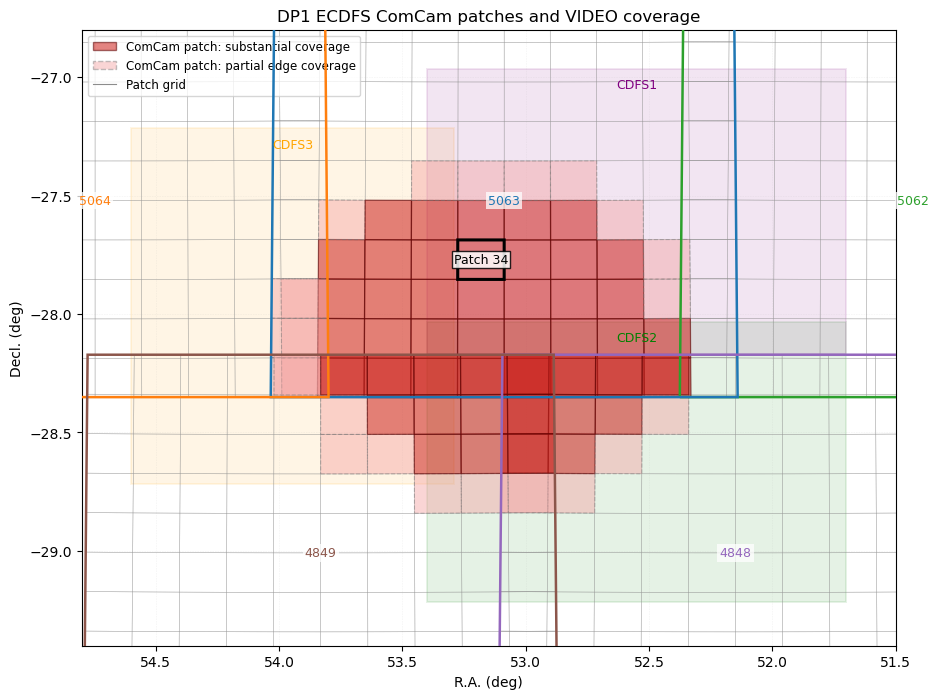

Saved PNG: data/image_products/dp1_ecdfs_comcam_patch_coverage_simple.png
Saved PDF: data/image_products/dp1_ecdfs_comcam_patch_coverage_simple.pdf


In [12]:
# ------------------------------------------------------------
# Simplified coverage map:
#   dark red  = substantial ComCam coverage
#   light red = partial/boundary coverage
# ------------------------------------------------------------

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ------------------------------------------------------------
# Build a lookup table from the cached coverage table
# ------------------------------------------------------------

coverage_lookup = (
    coverage_table
    .set_index(["tract", "patch"])
    .to_dict(orient="index")
)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 8.0),
)


# ------------------------------------------------------------
# Approximate VIDEO field envelopes
# ------------------------------------------------------------

for field_name, field in video_fields.items():

    width = field["ra_max"] - field["ra_min"]
    height = field["dec_max"] - field["dec_min"]

    rectangle = Rectangle(
        (field["ra_min"], field["dec_min"]),
        width,
        height,
        facecolor=field["color"],
        edgecolor=field["color"],
        linewidth=1.4,
        alpha=0.10,
        zorder=1,
    )

    ax.add_patch(rectangle)

    ax.text(
        0.5 * (field["ra_min"] + field["ra_max"]),
        field["dec_max"] - 0.04,
        field_name,
        ha="center",
        va="top",
        fontsize=9,
        color=field["color"],
        zorder=7,
    )


# ------------------------------------------------------------
# First layer: full SkyMap patch grid
# ------------------------------------------------------------

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    number_of_patches = tract_info.getNumPatches()

    for patch_y in range(number_of_patches[1]):
        for patch_x in range(number_of_patches[0]):

            patch_info = tract_info.getPatchInfo(
                (patch_x, patch_y)
            )

            patch_vertices = bbox_sky_vertices(
                patch_info.getInnerBBox(),
                tract_wcs,
            )

            polygon = Polygon(
                patch_vertices,
                closed=True,
                facecolor="none",
                edgecolor="0.55",
                linewidth=0.35,
                alpha=0.55,
                zorder=2,
            )

            ax.add_patch(polygon)


# ------------------------------------------------------------
# Second layer: simplified ComCam coverage
# ------------------------------------------------------------

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    number_of_patches = tract_info.getNumPatches()

    for patch_y in range(number_of_patches[1]):
        for patch_x in range(number_of_patches[0]):

            patch_info = tract_info.getPatchInfo(
                (patch_x, patch_y)
            )

            patch_id = patch_info.getSequentialIndex()

            key = (tract_id, patch_id)

            if key not in coverage_lookup:
                continue

            row = coverage_lookup[key]

            # Require useful coverage in at least 4 bands.
            if row["n_bands"] < 4:
                continue

            median_fraction = float(
                row["median_valid_fraction"]
            )

            patch_vertices = bbox_sky_vertices(
                patch_info.getInnerBBox(),
                tract_wcs,
            )

            # Two simple states only:
            # substantial coverage versus partial edge coverage.
            if median_fraction >= 0.50:
                facecolor = "#cc1f1a"   # dark red
                edgecolor = "#5c0000"
                alpha = 0.55
                linestyle = "-"
                linewidth = 0.9
            else:
                facecolor = "#f4a3a3"   # light red
                edgecolor = "#777777"
                alpha = 0.45
                linestyle = "--"
                linewidth = 0.8

            polygon = Polygon(
                patch_vertices,
                closed=True,
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth,
                linestyle=linestyle,
                alpha=alpha,
                zorder=3,
            )

            ax.add_patch(polygon)



# ------------------------------------------------------------
# Highlight one selected patch
# ------------------------------------------------------------

TRACT_FOR_PATCH = 5063
PATCH_FOR_PATCH = 34

tract_info = sky_map[TRACT_FOR_PATCH]
tract_wcs = tract_info.getWcs()

number_of_patches = tract_info.getNumPatches()

for patch_y in range(number_of_patches[1]):
    for patch_x in range(number_of_patches[0]):

        patch_info = tract_info.getPatchInfo(
            (patch_x, patch_y)
        )

        patch_id = patch_info.getSequentialIndex()

        if patch_id != PATCH_FOR_PATCH:
            continue

        patch_vertices = bbox_sky_vertices(
            patch_info.getInnerBBox(),
            tract_wcs,
        )

        highlight_polygon = Polygon(
            patch_vertices,
            closed=True,
            facecolor="none",
            edgecolor="black",
            linewidth=2.2,
            linestyle="-",
            zorder=10,
        )

        ax.add_patch(highlight_polygon)

        patch_centre = np.mean(
            patch_vertices,
            axis=0,
        )

        ax.text(
            patch_centre[0],
            patch_centre[1],
            f"Patch {PATCH_FOR_PATCH}",
            ha="center",
            va="center",
            fontsize=9,
            color="black",
            bbox={
                "facecolor": "white",
                "edgecolor": "black",
                "alpha": 0.85,
                "pad": 1.5,
            },
            zorder=11,
        )


# ------------------------------------------------------------
# Third layer: tract boundaries
# ------------------------------------------------------------

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    tract_vertices = bbox_sky_vertices(
        tract_info.getBBox(),
        tract_wcs,
    )

    add_sky_polygon(
        ax,
        tract_vertices,
        edgecolor=TRACT_COLOURS[tract_id],
        linewidth=1.8,
        facecolor="none",
        zorder=6,
    )

    tract_centre = tract_info.getCtrCoord()

    ax.text(
        tract_centre.getRa().asDegrees(),
        tract_centre.getDec().asDegrees(),
        str(tract_id),
        ha="center",
        va="center",
        fontsize=9,
        color=TRACT_COLOURS[tract_id],
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.75,
            "pad": 1.5,
        },
        zorder=8,
    )


# ------------------------------------------------------------
# Small, simple legend
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor="#cc1f1a",
        edgecolor="#5c0000",
        label="ComCam patch: substantial coverage",
        alpha=0.55,
    ),
    Patch(
        facecolor="#f4a3a3",
        edgecolor="#777777",
        linestyle="--",
        label="ComCam patch: partial edge coverage",
        alpha=0.45,
    ),
    Line2D(
        [0], [0],
        color="0.55",
        linewidth=0.8,
        label="Patch grid",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    fontsize=8.5,
    frameon=True,
)


# ------------------------------------------------------------
# Appearance
# ------------------------------------------------------------

ax.set_xlabel("R.A. (deg)")
ax.set_ylabel("Decl. (deg)")

ax.set_title(
    "DP1 ECDFS ComCam patches and VIDEO coverage"
)

ax.set_xlim(54.8, 51.5)
ax.set_ylim(-29.4, -26.8)

ax.grid(
    linestyle=":",
    linewidth=0.45,
    alpha=0.25,
)

ax.set_aspect("auto")


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

coverage_simple_png = (
    OUTDIR / "dp1_ecdfs_comcam_patch_coverage_simple.png"
)

coverage_simple_pdf = (
    OUTDIR / "dp1_ecdfs_comcam_patch_coverage_simple.pdf"
)

fig.savefig(
    coverage_simple_png,
    dpi=180,
)

fig.savefig(
    coverage_simple_pdf,
    dpi=180,
)

plt.show()

print("Saved PNG:", coverage_simple_png)
print("Saved PDF:", coverage_simple_pdf)

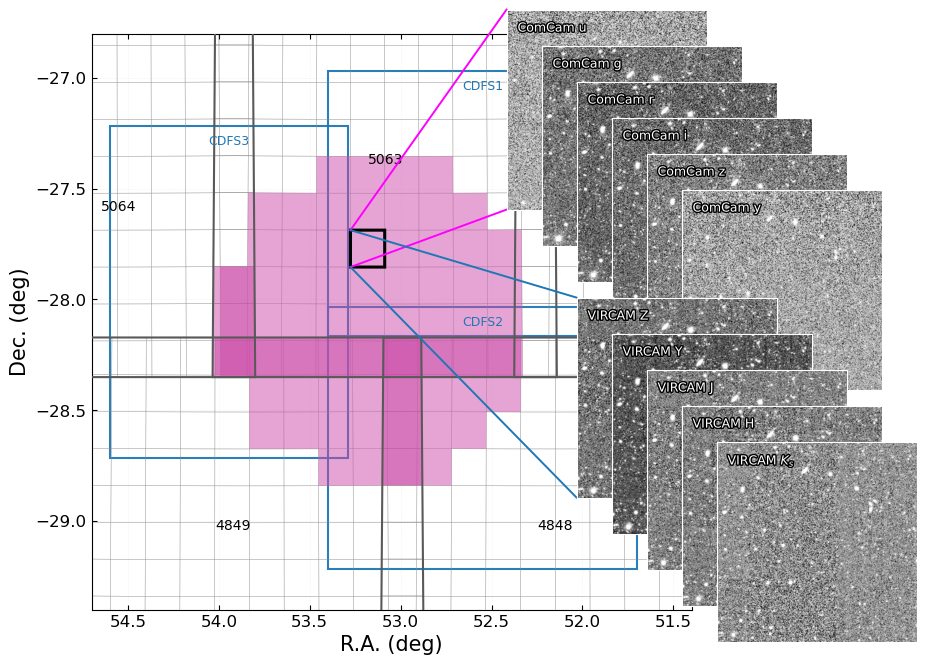

Saved PNG: data/image_products/dp1_ecdfs_map_plus_patch34_boxes.png
Saved PDF: data/image_products/dp1_ecdfs_map_plus_patch34_boxes.pdf


In [13]:
# ============================================================
# Combined figure:
#   ECDFS coverage map + 11-band representative patch boxes
# ============================================================

from astropy.visualization import ImageNormalize, AsinhStretch
from matplotlib.patches import Polygon, Rectangle
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import matplotlib as mpl

mpl.rcParams["pdf.compression"] = 9

# ------------------------------------------------------------
# Representative patch
# ------------------------------------------------------------

TRACT_FOR_PATCH = 5063
PATCH_FOR_PATCH = 34

COMCAM_BANDS = ["u", "g", "r", "i", "z", "y"]
VIRCAM_BANDS = ["Z", "Y", "J", "H", "K"]
ALL_BANDS = COMCAM_BANDS + VIRCAM_BANDS

PANEL_LABELS = {
    "u": "ComCam u",
    "g": "ComCam g",
    "r": "ComCam r",
    "i": "ComCam i",
    "z": "ComCam z",
    "y": "ComCam y",
    "Z": "VIRCAM Z",
    "Y": "VIRCAM Y",
    "J": "VIRCAM J",
    "H": "VIRCAM H",
    "K": r"VIRCAM $K_s$",
}

DISPLAY_CMAP = "gray"
DISPLAY_ASINH_A = 0.18
MAX_DISPLAY_PIXELS = 350

# One colour for all VIDEO field outlines
VISTA_COLOR = "tab:blue"


# ------------------------------------------------------------
# Patch-coverage lookup
# ------------------------------------------------------------

coverage_lookup = (
    coverage_table
    .set_index(["tract", "patch"])
    .to_dict(orient="index")
)


# ------------------------------------------------------------
# Loaders
# ------------------------------------------------------------

def load_comcam_patch(band):
    refs = list(
        butler.query_datasets(
            "deep_coadd",
            tract=TRACT_FOR_PATCH,
            patch=PATCH_FOR_PATCH,
            where=f"band = '{band}'",
            explain=False,
        )
    )

    if not refs:
        raise RuntimeError(
            f"No ComCam {band}-band dataset for "
            f"tract={TRACT_FOR_PATCH}, patch={PATCH_FOR_PATCH}."
        )

    ref = sorted(
        refs,
        key=lambda item: str(item.run),
    )[-1]

    return butler.get(ref), ref


def load_vista_patch(band):
    refs = list(
        registry_vista.queryDatasets(
            VIRCAM_DATASET_TYPE,
            dataId={
                "skymap": SKYMAP,
                "tract": TRACT_FOR_PATCH,
                "patch": PATCH_FOR_PATCH,
                "band": band,
            },
            collections=VIRCAM_SEARCH_COLLECTIONS,
        )
    )

    if not refs:
        raise RuntimeError(
            f"No VIRCAM {band}-band dataset for "
            f"tract={TRACT_FOR_PATCH}, patch={PATCH_FOR_PATCH}."
        )

    ref = sorted(
        refs,
        key=lambda item: str(item.run),
    )[-1]

    return butler_vista.get(ref), ref


def get_no_data_mask(exposure):
    mask = exposure.mask
    plane_dict = mask.getMaskPlaneDict()

    if "NO_DATA" not in plane_dict:
        return np.zeros(mask.array.shape, dtype=bool)

    bit = plane_dict["NO_DATA"]

    return (
        np.asarray(mask.array, dtype=np.int64)
        & (1 << bit)
    ) != 0


def make_patch_display(exposure):
    image = np.asarray(
        exposure.image.array,
        dtype=float,
    ).copy()

    no_data = get_no_data_mask(exposure)
    image[no_data] = np.nan

    ny, nx = image.shape

    display_step = max(
        1,
        int(
            np.ceil(
                max(nx, ny) / MAX_DISPLAY_PIXELS
            )
        ),
    )

    display_image = image[
        ::display_step,
        ::display_step,
    ]

    valid = display_image[
        np.isfinite(display_image)
    ]

    if valid.size == 0:
        raise RuntimeError(
            "No valid pixels available for display."
        )

    p05 = np.percentile(valid, 5.0)
    p995 = np.percentile(valid, 98.0)

    norm = ImageNormalize(
        vmin=p05,
        vmax=p995,
        stretch=AsinhStretch(a=0.10),
        clip=True,
    )

    return display_image, norm


# ------------------------------------------------------------
# Load all 11 displays
# ------------------------------------------------------------

display_images = {}
display_norms = {}

for band in ALL_BANDS:

    if band in COMCAM_BANDS:
        exposure, _ = load_comcam_patch(band)
    else:
        exposure, _ = load_vista_patch(band)

    display_image, norm = make_patch_display(exposure)

    display_images[band] = display_image
    display_norms[band] = norm


patch_cmap = plt.get_cmap(DISPLAY_CMAP).copy()
patch_cmap.set_bad("0.75")


# ------------------------------------------------------------
# Figure canvas
# ------------------------------------------------------------

fig = plt.figure(figsize=(10, 8))

# Main map axis.
ax_map = fig.add_axes([0.36, 0.15, 0.60, 0.72])


# ------------------------------------------------------------
# Background map
# ------------------------------------------------------------

# VIDEO field envelopes
for field_name, field in video_fields.items():

    width = field["ra_max"] - field["ra_min"]
    height = field["dec_max"] - field["dec_min"]

    rectangle = Rectangle(
        (field["ra_min"], field["dec_min"]),
        width,
        height,
        facecolor="none",
        edgecolor=VISTA_COLOR,
        linewidth=1.5,
        alpha=0.95,
        zorder=1,
    )

    ax_map.add_patch(rectangle)

    ax_map.text(
        0.5 * (field["ra_min"] + field["ra_max"]),
        field["dec_max"] - 0.04,
        field_name,
        ha="center",
        va="top",
        fontsize=9,
        color=VISTA_COLOR,
        zorder=7,
    )


# ------------------------------------------------------------
# Full patch grid
# ------------------------------------------------------------

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    number_of_patches = tract_info.getNumPatches()

    for patch_y in range(number_of_patches[1]):
        for patch_x in range(number_of_patches[0]):

            patch_info = tract_info.getPatchInfo(
                (patch_x, patch_y)
            )

            patch_vertices = bbox_sky_vertices(
                patch_info.getInnerBBox(),
                tract_wcs,
            )

            polygon = Polygon(
                patch_vertices,
                closed=True,
                facecolor="none",
                edgecolor="0.55",
                linewidth=0.35,
                alpha=0.55,
                zorder=2,
            )

            ax_map.add_patch(polygon)


# ------------------------------------------------------------
# ComCam coverage
# Shade patches containing valid imaging in >=4 bands
# with one uniform magenta colour.
# ------------------------------------------------------------

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    number_of_patches = tract_info.getNumPatches()

    for patch_y in range(number_of_patches[1]):
        for patch_x in range(number_of_patches[0]):

            patch_info = tract_info.getPatchInfo(
                (patch_x, patch_y)
            )

            patch_id = patch_info.getSequentialIndex()

            key = (tract_id, patch_id)

            if key not in coverage_lookup:
                continue

            row = coverage_lookup[key]

            if row["n_bands"] < 4:
                continue

            patch_vertices = bbox_sky_vertices(
                patch_info.getInnerBBox(),
                tract_wcs,
            )

            polygon = Polygon(
                patch_vertices,
                closed=True,
                facecolor="#cc4aa8",
                edgecolor="none",
                alpha=0.50,
                zorder=3,
            )

            ax_map.add_patch(polygon)


# ------------------------------------------------------------
# Tract boundaries and tract labels
# ------------------------------------------------------------

TRACT_LABEL_POSITIONS = {
    5062: (51.65, -27.40),
    5063: (53.08, -27.37),
    5064: (54.55, -27.58),
    4848: (52.15, -29.02),
    4849: (53.92, -29.02),
}

for tract_id in TRACT_IDS:

    tract_info = sky_map[tract_id]
    tract_wcs = tract_info.getWcs()

    tract_vertices = bbox_sky_vertices(
        tract_info.getBBox(),
        tract_wcs,
    )

    add_sky_polygon(
        ax_map,
        tract_vertices,
        edgecolor="0.35",
        linewidth=1.5,
        facecolor="none",
        zorder=6,
    )

    label_ra, label_dec = TRACT_LABEL_POSITIONS[
        tract_id
    ]

    ax_map.text(
        label_ra,
        label_dec,
        str(tract_id),
        ha="center",
        va="center",
        fontsize=10,
        color="black",
        zorder=8,
    )


# ------------------------------------------------------------
# Highlight representative patch
# ------------------------------------------------------------

tract_info = sky_map[TRACT_FOR_PATCH]
tract_wcs = tract_info.getWcs()

selected_vertices = None

number_of_patches = tract_info.getNumPatches()

for patch_y in range(number_of_patches[1]):
    for patch_x in range(number_of_patches[0]):

        patch_info = tract_info.getPatchInfo(
            (patch_x, patch_y)
        )

        patch_id = patch_info.getSequentialIndex()

        if patch_id != PATCH_FOR_PATCH:
            continue

        selected_vertices = bbox_sky_vertices(
            patch_info.getInnerBBox(),
            tract_wcs,
        )

        highlight_polygon = Polygon(
            selected_vertices,
            closed=True,
            facecolor="none",
            edgecolor="black",
            linewidth=2.2,
            zorder=10,
        )

        ax_map.add_patch(
            highlight_polygon
        )


# ------------------------------------------------------------
# Map appearance
# ------------------------------------------------------------

ax_map.set_xlabel("R.A. (deg)", fontsize=15)
ax_map.set_ylabel("Dec. (deg)", fontsize=15)

ax_map.set_xlim(54.7, 51.4)
ax_map.set_ylim(-29.4, -26.8)

ax_map.grid(
    linestyle=":",
    linewidth=0.45,
    alpha=0.25,
)

ax_map.set_aspect("auto")

# Ticks on all sides and pointing inward
ax_map.tick_params(
    axis="both",
    which="both",
    direction="in",
    top=True,
    right=True,
    labelsize=12,
)


# ------------------------------------------------------------
# 11 patch boxes: staircase layout
# ------------------------------------------------------------

thumbnail_axes = {}


# ------------------------------------------------------------
# ComCam staircase
# ------------------------------------------------------------

COMCAM_X0 = 0.75
COMCAM_Y0 = 0.65

COMCAM_DX = 0.035
COMCAM_DY = -0.045

COMCAM_WIDTH = 0.25
COMCAM_HEIGHT = 0.25


for index, band in enumerate(COMCAM_BANDS):

    x = COMCAM_X0 + index * COMCAM_DX
    y = COMCAM_Y0 + index * COMCAM_DY

    ax = fig.add_axes(
        [
            x,
            y,
            COMCAM_WIDTH,
            COMCAM_HEIGHT,
        ]
    )

    ax.set_facecolor("white")
    ax.patch.set_alpha(1.0)
    ax.set_zorder(20 + index)

    thumbnail_axes[band] = ax


# ------------------------------------------------------------
# VIRCAM staircase
# ------------------------------------------------------------

VIRCAM_X0 = 0.82
VIRCAM_Y0 = 0.29

VIRCAM_DX = 0.035
VIRCAM_DY = -0.045

VIRCAM_WIDTH = 0.25
VIRCAM_HEIGHT = 0.25


for index, band in enumerate(VIRCAM_BANDS):

    x = VIRCAM_X0 + index * VIRCAM_DX
    y = VIRCAM_Y0 + index * VIRCAM_DY

    ax = fig.add_axes(
        [
            x,
            y,
            VIRCAM_WIDTH,
            VIRCAM_HEIGHT,
        ]
    )

    ax.set_facecolor("white")
    ax.patch.set_alpha(1.0)
    ax.set_zorder(50 + index)

    thumbnail_axes[band] = ax


# ------------------------------------------------------------
# Draw all thumbnails
# ------------------------------------------------------------

for band in ALL_BANDS:

    ax = thumbnail_axes[band]

    ax.imshow(
        display_images[band],
        origin="lower",
        cmap=patch_cmap,
        norm=display_norms[band],
        # Slight display smoothing only
        interpolation="bilinear",
        rasterized=True,
        alpha=1.0,
    )

    ax.text(
        0.055,
        0.94,
        PANEL_LABELS[band],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color="white",
        path_effects=[
            pe.withStroke(
                linewidth=2.0,
                foreground="black",
            )
        ],
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("white")


# ------------------------------------------------------------
# Connector lines:
# two lines to ComCam u and two lines to VIRCAM Z
# ------------------------------------------------------------

fig.canvas.draw()

if selected_vertices is not None:

    # Convert selected patch vertices to figure coordinates.
    patch_fig_vertices = (
        fig.transFigure
        .inverted()
        .transform(
            ax_map.transData.transform(
                selected_vertices
            )
        )
    )

    pxmin = patch_fig_vertices[:, 0].min()
    pxmax = patch_fig_vertices[:, 0].max()
    pymin = patch_fig_vertices[:, 1].min()
    pymax = patch_fig_vertices[:, 1].max()

    # Right-hand corners of the selected patch.
    patch_tr = (
        pxmin,
        pymax,
    )

    patch_br = (
        pxmin,
        pymin,
    )


    # --------------------------------------------------------
    # First ComCam box = u
    # left-side corners
    # --------------------------------------------------------

    comcam_box = thumbnail_axes["u"].get_position()

    comcam_tl = (
        comcam_box.x0,
        comcam_box.y1,
    )

    comcam_bl = (
        comcam_box.x0,
        comcam_box.y0,
    )


    # --------------------------------------------------------
    # First VIRCAM box = Z
    # left-side corners
    # --------------------------------------------------------

    vircam_box = thumbnail_axes["Z"].get_position()

    vircam_tl = (
        vircam_box.x0,
        vircam_box.y1,
    )

    vircam_bl = (
        vircam_box.x0,
        vircam_box.y0,
    )


    line_kwargs_comcam = dict(
        transform=fig.transFigure,
        color="magenta",
        linewidth=1.4,
        zorder=15,
    )

    line_kwargs_vircam = dict(
        transform=fig.transFigure,
        color="tab:blue",
        linewidth=1.4,
        zorder=15,
    )


    connector_lines = [

        # ComCam u
        Line2D(
            [patch_tr[0], comcam_tl[0]],
            [patch_tr[1], comcam_tl[1]],
            **line_kwargs_comcam,
        ),

        Line2D(
            [patch_br[0], comcam_bl[0]],
            [patch_br[1], comcam_bl[1]],
            **line_kwargs_comcam,
        ),

        # VIRCAM Z
        Line2D(
            [patch_tr[0], vircam_tl[0]],
            [patch_tr[1], vircam_tl[1]],
            **line_kwargs_vircam,
        ),

        Line2D(
            [patch_br[0], vircam_bl[0]],
            [patch_br[1], vircam_bl[1]],
            **line_kwargs_vircam,
        ),
    ]

    fig.lines.extend(
        connector_lines
    )


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

combined_png = OUTDIR / (
    f"dp1_ecdfs_map_plus_patch34_boxes.png"
)

combined_pdf = OUTDIR / (
    f"dp1_ecdfs_map_plus_patch34_boxes.pdf"
)

fig.savefig(
    combined_png,
    dpi=180,
    bbox_inches="tight",
    pad_inches=0.02,
)

fig.savefig(
    combined_pdf,
    dpi=130,
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.show()

print("Saved PNG:", combined_png)
print("Saved PDF:", combined_pdf)